#Tratamiento de las variables categóricas:

In [62]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

In [63]:
from sklearn.feature_selection import RFE
from sklearn.svm import SVR

In [64]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
df = pd.read_csv("/content/drive/MyDrive/Machine Learning - Python/Datasets - Machine Learning/ecom-expense/Ecom Expense.csv")

In [66]:
df.head()

,Transaction ID,Age,Items,Monthly Income,Transaction Time,Record,Gender,City Tier,Total Spend
0,TXN001,42,10,7313,627.668127,5,Female,Tier 1,4198.385084
1,TXN002,24,8,17747,126.904567,3,Female,Tier 2,4134.976648
2,TXN003,47,11,22845,873.469701,2,Male,Tier 2,5166.614455
3,TXN004,50,11,18552,380.219428,7,Female,Tier 1,7784.447676
4,TXN005,60,2,14439,403.374223,2,Female,Tier 2,3254.160485


In [67]:
dummy_gender = pd.get_dummies(df["Gender"], prefix = "Gender")
dummy_city_tier = pd.get_dummies(df["City Tier"], prefix = "City")

In [68]:
dummy_gender.head()

,Gender_Female,Gender_Male
0,1,0
1,1,0
2,0,1
3,1,0
4,1,0


In [69]:
dummy_city_tier.head()

,City_Tier 1,City_Tier 2,City_Tier 3
0,1,0,0
1,0,1,0
2,0,1,0
3,1,0,0
4,0,1,0


In [70]:
column_names = df.columns.values.tolist()
column_names

['Transaction ID',
 'Age ',
 ' Items ',
 'Monthly Income',
 'Transaction Time',
 'Record',
 'Gender',
 'City Tier',
 'Total Spend']

In [71]:
df_new = df.join(dummy_gender)
column_names = df_new.columns.values.tolist()
df_new.head()

,Transaction ID,Age,Items,Monthly Income,Transaction Time,Record,Gender,City Tier,Total Spend,Gender_Female,Gender_Male
0,TXN001,42,10,7313,627.668127,5,Female,Tier 1,4198.385084,1,0
1,TXN002,24,8,17747,126.904567,3,Female,Tier 2,4134.976648,1,0
2,TXN003,47,11,22845,873.469701,2,Male,Tier 2,5166.614455,0,1
3,TXN004,50,11,18552,380.219428,7,Female,Tier 1,7784.447676,1,0
4,TXN005,60,2,14439,403.374223,2,Female,Tier 2,3254.160485,1,0


In [72]:
column_names

['Transaction ID',
 'Age ',
 ' Items ',
 'Monthly Income',
 'Transaction Time',
 'Record',
 'Gender',
 'City Tier',
 'Total Spend',
 'Gender_Female',
 'Gender_Male']

In [73]:
df_new = df_new.join(dummy_city_tier)
column_names = df_new.columns.values.tolist()

In [74]:
df_new.head()

,Transaction ID,Age,Items,Monthly Income,Transaction Time,Record,Gender,City Tier,Total Spend,Gender_Female,Gender_Male,City_Tier 1,City_Tier 2,City_Tier 3
0,TXN001,42,10,7313,627.668127,5,Female,Tier 1,4198.385084,1,0,1,0,0
1,TXN002,24,8,17747,126.904567,3,Female,Tier 2,4134.976648,1,0,0,1,0
2,TXN003,47,11,22845,873.469701,2,Male,Tier 2,5166.614455,0,1,0,1,0
3,TXN004,50,11,18552,380.219428,7,Female,Tier 1,7784.447676,1,0,1,0,0
4,TXN005,60,2,14439,403.374223,2,Female,Tier 2,3254.160485,1,0,0,1,0


In [75]:
feature_cols = ["Monthly Income", "Transaction Time",
                "Gender_Female", "Gender_Male",
                "City_Tier 1", "City_Tier 2",
                "City_Tier 3", "Record"]

In [76]:
feature_cols

['Monthly Income',
 'Transaction Time',
 'Gender_Female',
 'Gender_Male',
 'City_Tier 1',
 'City_Tier 2',
 'City_Tier 3',
 'Record']

In [77]:
X = df_new[feature_cols]
Y = df_new["Total Spend"]

In [78]:
estimator = SVR(kernel = "linear")
selector_0 = RFE(estimator, n_features_to_select = 6, step = 1)
selector = selector_0.fit(X, Y)

In [79]:
selector.support_

array([False, False,  True,  True,  True,  True,  True,  True])

In [80]:
selector.ranking_

array([2, 3, 1, 1, 1, 1, 1, 1])

In [81]:
lm = LinearRegression()
lm.fit(X, Y)

LinearRegression()

In [82]:
lm.intercept_

-79.41713030137362

In [83]:
lm.coef_

array([ 1.47538980e-01,  1.54946125e-01, -1.31025013e+02,  1.31025013e+02,
        7.67643260e+01,  5.51389743e+01, -1.31903300e+02,  7.72233446e+02])

In [84]:
list(zip(feature_cols, lm.coef_))

[('Monthly Income', 0.1475389804920575),
 ('Transaction Time', 0.1549461254958957),
 ('Gender_Female', -131.02501325554573),
 ('Gender_Male', 131.02501325554587),
 ('City_Tier 1', 76.76432601049486),
 ('City_Tier 2', 55.138974309232765),
 ('City_Tier 3', -131.90330031972772),
 ('Record', 772.2334457445643)]

In [85]:
# Para calcular el r^2 ajustado: (Aquí resulta bajo)
lm.score(X, Y)

0.9179923586131016

###En este punto, volvemos a lineas previas, para redefinir nuestro conjunto de variables predictoras, hasta obtener resultados deseables.

In [86]:
# El modelo puede ser escrito como:
'''
Total_Spend = -79.41713030137271
                + (df_new['Monthly Income'] * 0.1475389804920575)
                + (df_new['Transaction Time'] * 0.15494612549589526)
                + (df_new['Gender_Female'] * (-131.02501325554573))
                + (df_new['Gender_Male'] * 131.02501325554587)
                + (df_new['City_Tier 1'] * 76.76432601049483)
                + (df_new['City_Tier 2'] * 55.13897430923282)
                + (df_new['City_Tier 3'] * (-131.90330031972766))
                + (df_new['Record'] * 772.2334457445643)
 '''
 # Luego, esta fórmula puede incluirse en df_new, con el nombre de prediction

df_new["Prediction"] = -79.41713030137271 + (df_new['Monthly Income'] * 0.1475389804920575) + (df_new['Transaction Time'] * 0.15494612549589526) + (df_new['Gender_Female'] * (-131.02501325554573)) + (df_new['Gender_Male'] * 131.02501325554587) + (df_new['City_Tier 1'] * 76.76432601049483) + (df_new['City_Tier 2'] * 55.13897430923282) + (df_new['City_Tier 3'] * (-131.90330031972766)) + (df_new['Record'] * 772.2334457445643)

In [87]:
df_new.head()

,Transaction ID,Age,Items,Monthly Income,Transaction Time,Record,Gender,City Tier,Total Spend,Gender_Female,Gender_Male,City_Tier 1,City_Tier 2,City_Tier 3,Prediction
0,TXN001,42,10,7313,627.668127,5,Female,Tier 1,4198.385084,1,0,1,0,0,4903.696720
1,TXN002,24,8,17747,126.904567,3,Female,Tier 2,4134.976648,1,0,0,1,0,4799.434826
2,TXN003,47,11,22845,873.469701,2,Male,Tier 2,5166.614455,0,1,0,1,0,5157.082504
3,TXN004,50,11,18552,380.219428,7,Female,Tier 1,7784.447676,1,0,1,0,0,8068.012996
4,TXN005,60,2,14439,403.374223,2,Female,Tier 2,3254.160485,1,0,0,1,0,3581.980335


In [88]:
# SSD = suma de los cuadrados de las diferencias

SSD = np.sum((df_new["Total Spend"] - df_new["Prediction"]) ** 2)
SSD

1517733985.3408167

In [89]:
RSE = np.sqrt(SSD / (len(df_new) - len(feature_cols) - 1))
RSE

803.1318809818166

In [90]:
sales_mean = np.mean(df_new["Total Spend"])
sales_mean

6163.176415976715

In [91]:
error = RSE / sales_mean
error

0.1303113568029416

###Otra posible forma de hacer el cálculo de las predicciones podría ser en usando la función predict del modelo lineal y añadiendolo como columna adicional al data frame:

`df_new["prediction"] = lm.predict(pd.DataFrame(df_new[feature_cols]))`

#IMPORTANTE: De aquí pueden surgir, por ejemplo, 6 modelos:

* Si es hombre y vive en City Tier 1.
* Si es hombre y vive en City Tier 2.
* Si es hombre y vive en City Tier 3.
* Si es mujer y vive en City Tier 1.
* Si es mujer y vive en City Tier 2.
* Si es mujer y vive en City Tier 3.



#Transformación de variables para conseguir una relación no lineal:

In [92]:
data_auto = pd.read_csv("/content/drive/MyDrive/Machine Learning - Python/Datasets - Machine Learning/auto/auto-mpg.csv")

In [93]:
data_auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


In [94]:
data_auto.columns.values

array(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'], dtype=object)

In [95]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Millas Por Galeón en función de Caballos De Potencia')

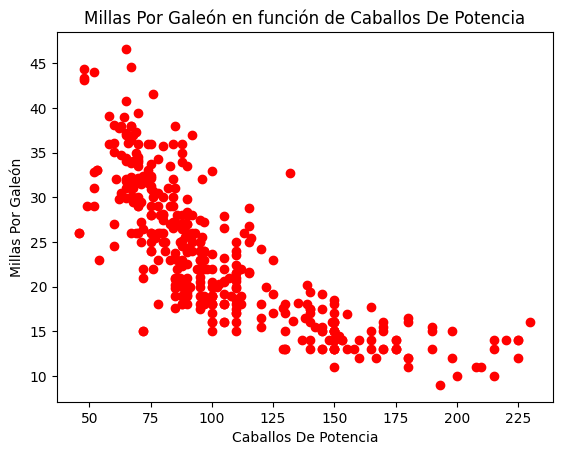

In [96]:
data_auto["mpg"] = data_auto["mpg"].dropna() # Eliminando filas con valores NaN
data_auto["horsepower"] = data_auto["horsepower"].dropna() # Eliminando filas con valores NaN
plt.plot(data_auto["horsepower"], data_auto["mpg"], "ro")
plt.xlabel("Caballos De Potencia")
plt.ylabel("Millas Por Galeón")
plt.title("Millas Por Galeón en función de Caballos De Potencia")

###Tratemos de vincular estas ideas con la regresión lineal

In [97]:
'''
Llevar a data_auto["horsepower"].fillna(data_auto["horsepower"].mean())
y data_auto["mpg"].fillna(data_auto["mpg"].mean()) a dataframe es lo más
recomendable, ya que en algunos casos se pueden estar trabajando con
solamente vectores
'''
X = pd.DataFrame(data_auto["horsepower"].fillna(data_auto["horsepower"].mean()))
Y = pd.DataFrame(data_auto["mpg"].fillna(data_auto["mpg"].mean()))

In [98]:
lm = LinearRegression()
lm.fit(X, Y)

LinearRegression()

Text(0.5, 1.0, 'Millas Por Galón en función de Caballos De Potencia')

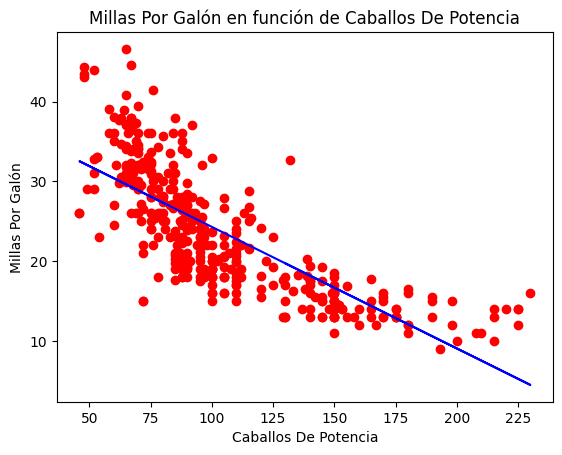

In [99]:
plt.plot(data_auto["horsepower"], data_auto["mpg"], "ro")
plt.plot(X, lm.predict(X), color = "blue")
plt.xlabel("Caballos De Potencia")
plt.ylabel("Millas Por Galón")
plt.title("Millas Por Galón en función de Caballos De Potencia")

In [100]:
lm.score(X, Y)

0.5746533406450252

In [101]:
# Cáculos pertinentes:
SSD = np.sum((Y - lm.predict(X)) ** 2)
RSE = np.sqrt(SSD / (len(X) - 1))
y_mean = np.mean(Y)
error = RSE / y_mean
SSD, RSE, y_mean, error * 100

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


(mpg    10315.75196
 dtype: float64,
 mpg    5.046879
 dtype: float64,
 mpg    23.514573
 dtype: float64,
 mpg    21.462773
 dtype: float64)

# Modelo de Regresión Cuadrático X^2:


In [102]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model

In [103]:
X_cuad = X ** 2

In [104]:
lm = LinearRegression()
lm.fit(X_cuad, Y)

LinearRegression()

In [105]:
lm.score(X_cuad, Y)

0.4849887034823205

In [106]:
# Cáculos pertinentes:
SSD = np.sum((Y - lm.predict(X_cuad)) ** 2)
RSE = np.sqrt(SSD / (len(X_cuad) - 1))
y_mean = np.mean(Y)
error = RSE / y_mean
SSD, RSE, y_mean, error * 100

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


(mpg    12490.350341
 dtype: float64,
 mpg    5.553411
 dtype: float64,
 mpg    23.514573
 dtype: float64,
 mpg    23.61689
 dtype: float64)

In [107]:
# De hecho, con las líneas anteriores, puedo definir una función:

def regression_validation(X_data, Y, lm):
    SSD = np.sum((Y - lm.predict(X_data)) ** 2)
    RSE = np.sqrt(SSD / (len(X_data) - 1))
    y_mean = np.mean(Y)
    error = RSE / y_mean
    return "SSD: {}".format(SSD), "RSE: {}".format(RSE), "y_mean: {}".format(y_mean), "error: {}".format(error * 100)

### Digamos que este procedimiento anterior no ha funcionado; probemos combinando el factor lineal y cuadrático:

* mpg = a + b * horsepower + c * horsepower ** 2

In [108]:
poly = PolynomialFeatures(degree = 2)

In [109]:
X_data = poly.fit_transform(X)

In [110]:
lm = LinearRegression()
lm.fit(X_data, Y)

LinearRegression()

In [111]:
lm.score(X_data, Y)

0.6439066584257469

In [112]:
lm.intercept_

array([55.02619245])

In [113]:
lm.coef_

array([[ 0.        , -0.43404318,  0.00112615]])

In [114]:
for d in range(2, 6):
    poly = PolynomialFeatures(degree = d)
    X_data = poly.fit_transform(X)
    lm = LinearRegression()
    lm.fit(X_data, Y)
    print('Regresión de grado: {}'.format(d))
    print('Factor r^2: ' + str(lm.score(X_data, Y)))
    print('intercepción: ' + str(lm.intercept_))
    print('Coeficientes: ' + str(lm.coef_))
    print(regression_validation(X_data, Y, lm))
    print('')

Regresión de grado: 2
Factor r^2: 0.6439066584257469
intercepción: [55.02619245]
Coeficientes: [[ 0.         -0.43404318  0.00112615]]
('SSD: mpg    8636.180644\ndtype: float64', 'RSE: mpg    4.617781\ndtype: float64', 'y_mean: mpg    23.514573\ndtype: float64', 'error: mpg    19.637955\ndtype: float64')

Regresión de grado: 3
Factor r^2: 0.6444678885560744
intercepción: [58.44877411]
Coeficientes: [[ 0.00000000e+00 -5.27113167e-01  1.89736722e-03 -1.95723195e-06]]
('SSD: mpg    8622.569367\ndtype: float64', 'RSE: mpg    4.614141\ndtype: float64', 'y_mean: mpg    23.514573\ndtype: float64', 'error: mpg    19.622473\ndtype: float64')

Regresión de grado: 4
Factor r^2: 0.6467674189704502
intercepción: [40.09664385]
Coeficientes: [[ 0.00000000e+00  1.62563541e-01 -7.10892744e-03  4.65580255e-05
  -9.15840092e-08]]
('SSD: mpg    8566.799832\ndtype: float64', 'RSE: mpg    4.599195\ndtype: float64', 'y_mean: mpg    23.514573\ndtype: float64', 'error: mpg    19.558913\ndtype: float64')

Regre

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/usr/local/lib/python3.10/dist-packages/

# El problema de los Outliers

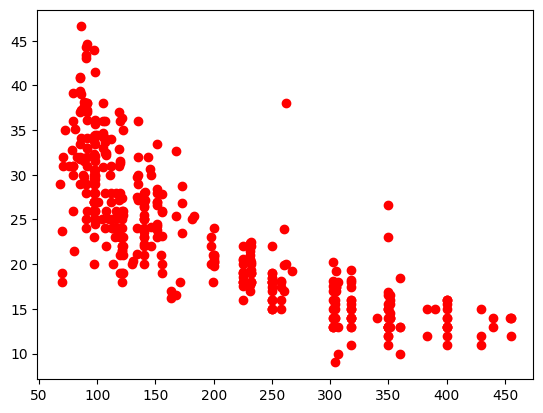

In [115]:
# Veamos el siguiente plot

plt.plot(data_auto['displacement'], data_auto['mpg'],'ro')

In [116]:
X = pd.DataFrame(data_auto['displacement'].fillna(data_auto['displacement'].mean()))
Y = pd.DataFrame(data_auto["mpg"].fillna(data_auto["mpg"].mean()))

lm = LinearRegression()
lm.fit(X, Y)

LinearRegression()

In [117]:
lm.score(X, Y)

0.6261049762826918

In [118]:
regression_validation(X, Y, lm)

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


('SSD: mpg    9067.917283\ndtype: float64',
 'RSE: mpg    4.731799\ndtype: float64',
 'y_mean: mpg    23.514573\ndtype: float64',
 'error: mpg    20.122835\ndtype: float64')

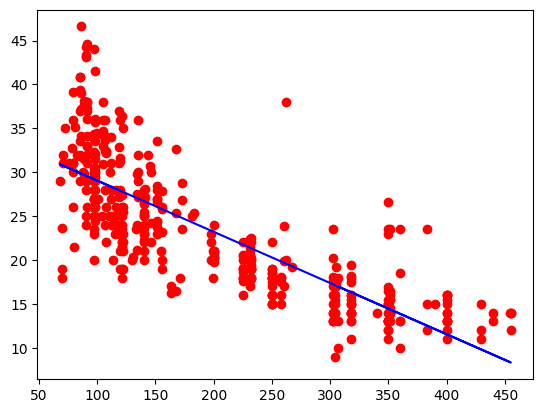

In [119]:
plt.plot(X, Y, 'ro')
plt.plot(X, lm.predict(X), color = 'blue')

In [120]:
'''
Del gráfico anterior, respecto al eje Y, podemos discriminar los puntos tales que para un x,
la diferencia entre la ordenada en la recta y la ordenada de la observación real, sea mayor
a 10 mpg.
'''

U = np.abs(Y - lm.predict(X)) >= 10
U

,mpg
0,False
1,False
2,False
3,False
4,False
...,...
401,False
402,True
403,False
404,False


In [122]:
list_index = []
for i in range(len(U)):
    if U['mpg'].iloc[i] == True:
        list_index.append(i)

In [123]:
list_index

[13, 78, 118, 251, 316, 329, 331, 332, 333, 336, 337, 372, 395, 402]

In [124]:
data_auto_clean = data_auto.drop(list_index)

In [125]:
X_clean = pd.DataFrame(data_auto_clean['displacement'].fillna(data_auto_clean['displacement'].mean()))
Y_clean = pd.DataFrame(data_auto_clean["mpg"].fillna(data_auto_clean["mpg"].mean()))

In [126]:
lm = LinearRegression()
lm.fit(X_clean, Y_clean)

LinearRegression()

In [127]:
lm.score(X_clean, Y_clean)

0.6866081894502284

In [128]:
regression_validation(X_clean, Y_clean, lm)

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


('SSD: mpg    6380.870695\ndtype: float64',
 'RSE: mpg    4.039723\ndtype: float64',
 'y_mean: mpg    23.033766\ndtype: float64',
 'error: mpg    17.538265\ndtype: float64')

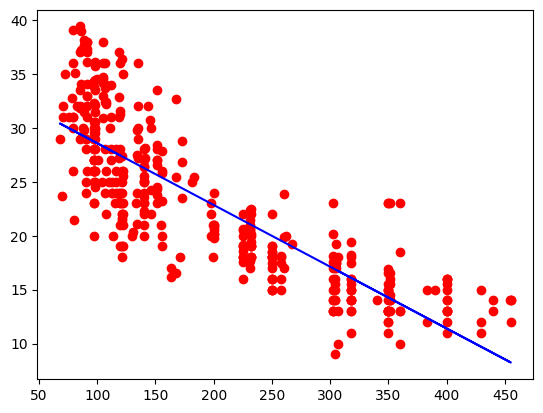

In [129]:
plt.plot(X_clean, Y_clean, 'ro')
plt.plot(X_clean, lm.predict(X_clean), color = 'blue')